# Autoencoders

**DISCLAIMER: This notebook setup to use an A100 on google colab.  If you can only access worse GPUs, you can try lowering the batch_size, however this will have a detrimental effect on one-to-one stitching.**

This notebook contains two example autoencoders, the first trained on MNIST and the second trained on CIFAR-10.  An autoencoder is neural network consisting of two parts: an encoder and a decoder.  As can be seen in the image below, the encoder compresses a given input to code.  This code part of the network is often called the bottleneck.  The decoder takes this code and produces an output.  

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png" width=500>

The output should be the same as the input and is leart using mean squared error loss:

$$ \mathcal{L} = \| input - output \|^2 $$

Since the bottleneck has a lower dimensionality than the input or output, the learning process forces the network to compress our input in a way that losses a little information as possible.  The more information that is retrained during the encoding, the better our output will be.

# MNIST

## Setup

Import python libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

Are we using a GPU or a CPU?

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset

We will use the MNIST dataset which contains 10,000s of $28 \times 28$ resolution images.

In [3]:
# Load MNIST dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 512
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:00<00:00, 42.6MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.24MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.90MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



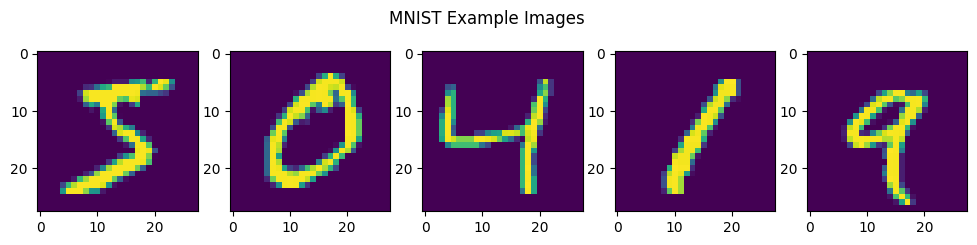

In [4]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
ax[0].imshow(mnist_dataset[0][0][0,:,:].numpy())
ax[1].imshow(mnist_dataset[1][0][0,:,:].numpy())
ax[2].imshow(mnist_dataset[2][0][0,:,:].numpy())
ax[3].imshow(mnist_dataset[3][0][0,:,:].numpy())
ax[4].imshow(mnist_dataset[4][0][0,:,:].numpy())


## Neural Network



We will be using a simple AutoEncoder here.  This network uses a combination of linear and convolution layers to compress an image into a smaller respresentation, then uses a decoder to network to reconstruct the image from this compressed representation.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, in_channels, img_size, latent_dim=128):
        super(Autoencoder, self).__init__()

        # What is the dimension of our image after going through the encoder?
        downsampled_size = int(img_size / 4)

        # Encoder
        self.encoder = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14

            # Second conv block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 7x7

            # Flatten and dense layers
            nn.Flatten(),
            nn.Linear(512 * downsampled_size * downsampled_size, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Dense layers
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 256 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(256 * downsampled_size * downsampled_size, 512 * downsampled_size * downsampled_size),
            nn.ReLU(),

            # Reshape layer
            nn.Unflatten(1, (512, downsampled_size, downsampled_size)),

            # First conv transpose block
            nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2),  # 14x14
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            # Second conv transpose block
            nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2),  # 28x28
            nn.ReLU(),
            nn.Conv2d(256, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


## Training

Train our autoencoder to reconstruct MNIST images.

In [6]:
def train_autoencoder(model, dataloader, epochs, learning_rate):

    # Initialize loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0
        for data in dataloader:
            # Sample data from dataset
            img, _ = data
            img = img.to(device)

            # Forward pass
            output = model(img)
            loss = criterion(output, img)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Log the loss for this epoch
        avg_loss = total_loss/len(dataloader)
        loss_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

    return model, loss_history

In [7]:
# Hyperparameters
epochs=25
learning_rate=1e-4

# Initialize model
img_size = 28
in_channels = 1
bottleneck_size = 128
mnist_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
mnist_model, loss_history = train_autoencoder(mnist_model, mnist_loader, epochs, learning_rate)

Epoch [1/25], Loss: 0.083963
Epoch [2/25], Loss: 0.047890
Epoch [3/25], Loss: 0.032105
Epoch [4/25], Loss: 0.024646
Epoch [5/25], Loss: 0.020366
Epoch [6/25], Loss: 0.017656
Epoch [7/25], Loss: 0.015708
Epoch [8/25], Loss: 0.014196
Epoch [9/25], Loss: 0.012688
Epoch [10/25], Loss: 0.011955
Epoch [11/25], Loss: 0.011064
Epoch [12/25], Loss: 0.010690
Epoch [13/25], Loss: 0.010122
Epoch [14/25], Loss: 0.009904
Epoch [15/25], Loss: 0.009434
Epoch [16/25], Loss: 0.009010
Epoch [17/25], Loss: 0.008835
Epoch [18/25], Loss: 0.008691
Epoch [19/25], Loss: 0.008378
Epoch [20/25], Loss: 0.008035
Epoch [21/25], Loss: 0.007834
Epoch [22/25], Loss: 0.007647
Epoch [23/25], Loss: 0.007480
Epoch [24/25], Loss: 0.007271
Epoch [25/25], Loss: 0.007120


Text(0.5, 1.0, 'MNIST Training Loss')

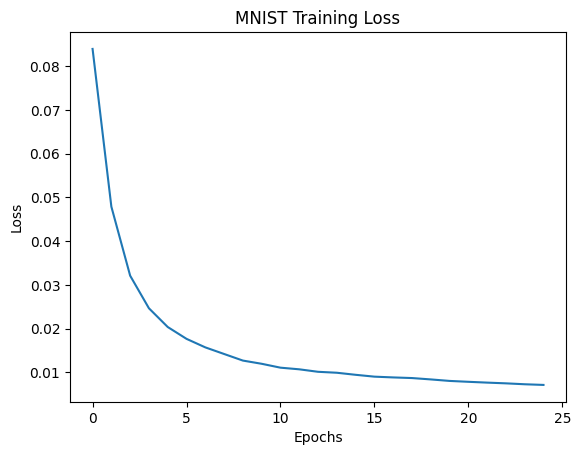

In [8]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MNIST Training Loss')

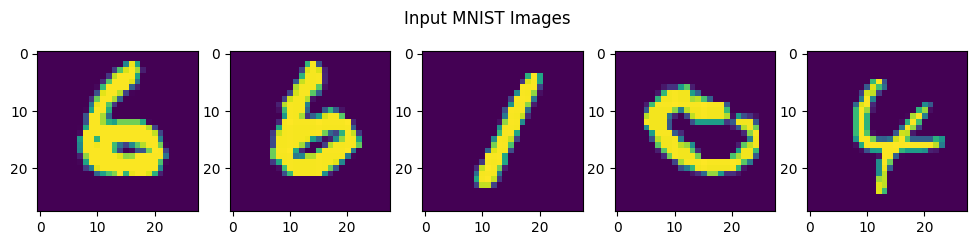

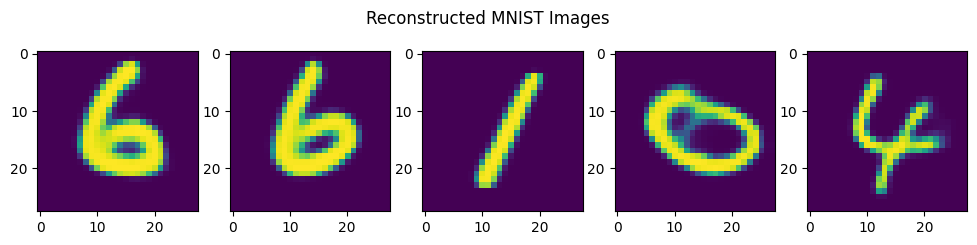

In [9]:
# Sample images
img, _ = next(iter(mnist_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input MNIST Images')
ax[0].imshow(img[0,0,:,:].cpu().numpy())
ax[1].imshow(img[1,0,:,:].cpu().numpy())
ax[2].imshow(img[2,0,:,:].cpu().numpy())
ax[3].imshow(img[3,0,:,:].cpu().numpy())
ax[4].imshow(img[4,0,:,:].cpu().numpy())
plt.show()

# Run images though the autoencdoer
output = mnist_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images')
ax[0].imshow(output[0,0,:,:].detach().cpu().numpy())
ax[1].imshow(output[1,0,:,:].detach().cpu().numpy())
ax[2].imshow(output[2,0,:,:].detach().cpu().numpy())
ax[3].imshow(output[3,0,:,:].detach().cpu().numpy())
ax[4].imshow(output[4,0,:,:].detach().cpu().numpy())
plt.show()

# CIFAR-10

## Dataset

Our second dataset the CIFAR-10 dataset.

In [10]:
# Load CIFAR-10 dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

cifar_dataset = datasets.CIFAR10(
    root='./data',  # Data will be downloaded to this directory
    train=True,     # Specify that we want the training dataset
    download=True,  # Download the dataset if it's not already downloaded
    transform=transform
)
cifar_test_dataset = datasets.CIFAR10(
    root='./data',  # Data will be downloaded to this directory
    train=False,     # Specify that we want the training dataset
    download=True,  # Download the dataset if it's not already downloaded
    transform=transform
)
cifar_loader = DataLoader(cifar_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
cifar_test_loader = DataLoader(cifar_test_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

100%|██████████| 170M/170M [00:01<00:00, 102MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


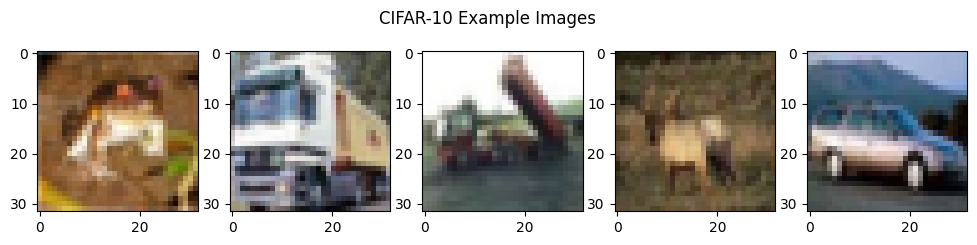

In [11]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('CIFAR-10 Example Images')
ax[0].imshow(np.transpose(cifar_dataset[0][0].numpy(), (1,2,0)))
ax[1].imshow(np.transpose(cifar_dataset[1][0].numpy(), (1,2,0)))
ax[2].imshow(np.transpose(cifar_dataset[2][0].numpy(), (1,2,0)))
ax[3].imshow(np.transpose(cifar_dataset[3][0].numpy(), (1,2,0)))
ax[4].imshow(np.transpose(cifar_dataset[4][0].numpy(), (1,2,0)))


## Training

Now we will train another autoencoder on the CIFAR-10 dataset.

In [12]:
# Initialize model, loss, and optimizer
img_size = 32
in_channels = 3
cifar_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
cifar_model, loss_history = train_autoencoder(cifar_model, cifar_loader, epochs, learning_rate)

Epoch [1/25], Loss: 0.048483
Epoch [2/25], Loss: 0.033733
Epoch [3/25], Loss: 0.031433
Epoch [4/25], Loss: 0.029446
Epoch [5/25], Loss: 0.027111
Epoch [6/25], Loss: 0.025491
Epoch [7/25], Loss: 0.023158
Epoch [8/25], Loss: 0.022058
Epoch [9/25], Loss: 0.021562
Epoch [10/25], Loss: 0.020879
Epoch [11/25], Loss: 0.020474
Epoch [12/25], Loss: 0.019801
Epoch [13/25], Loss: 0.019686
Epoch [14/25], Loss: 0.019308
Epoch [15/25], Loss: 0.018505
Epoch [16/25], Loss: 0.017429
Epoch [17/25], Loss: 0.016833
Epoch [18/25], Loss: 0.016527
Epoch [19/25], Loss: 0.016252
Epoch [20/25], Loss: 0.016038
Epoch [21/25], Loss: 0.015811
Epoch [22/25], Loss: 0.015556
Epoch [23/25], Loss: 0.015352
Epoch [24/25], Loss: 0.015067
Epoch [25/25], Loss: 0.014781


Text(0.5, 1.0, 'CIFAR-10 Training Loss')

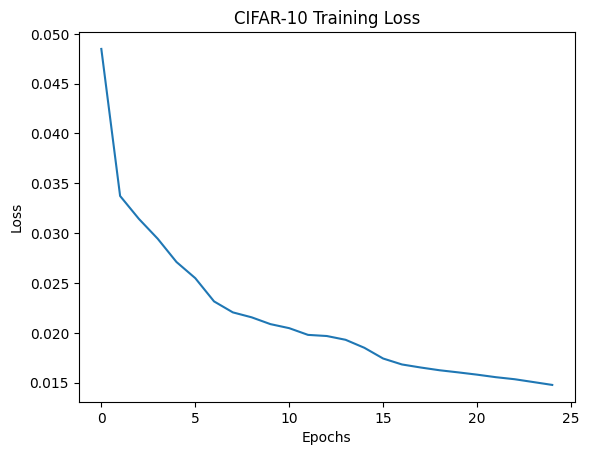

In [13]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-10 Training Loss')

Here we plot input images, and the image reconstructed by the autoencoder.

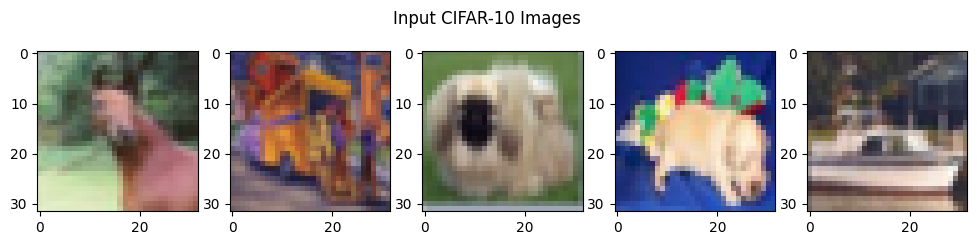

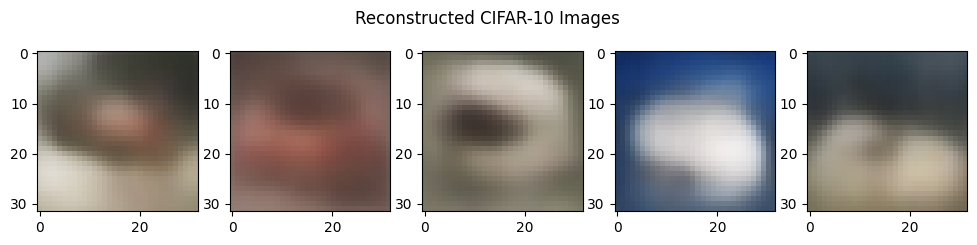

In [14]:
# Sample CIFAR-10 images
img, _ = next(iter(cifar_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input CIFAR-10 Images')
for i in range(5):
    ax[i].imshow(np.transpose(img[i].cpu().numpy(), (1,2,0)))
plt.show()

# Run images though the autoencdoer
output = cifar_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed CIFAR-10 Images')
for i in range(5):
    ax[i].imshow(np.transpose(output[i].detach().cpu().numpy(), (1,2,0)))


# Stitching

## Neural Network

Define a stitch which is a simple 1d convolution layer which will connect two sub-networks

In [15]:
class Stitch(nn.Module):

    def __init__(self, n_dims):
        super(Stitch, self).__init__()
        self.bn1 = nn.BatchNorm2d(n_dims)
        self.conv = nn.Conv2d(n_dims, n_dims, kernel_size=1, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(n_dims)

    def forward(self, x):
        out = self.bn1(x)
        out = self.conv(out)
        out = self.bn2(out)
        return out

In [16]:
class StichedAutoencoder(nn.Module):

    def __init__(self, encoder, decoder, bottleneck_size):
        super(StichedAutoencoder, self).__init__()
        self.bottleneck_size = bottleneck_size
        self.encoder = encoder
        self.stitch = Stitch(self.bottleneck_size)
        self.decoder = decoder

    def forward(self, x):
        x = self.encoder(x).view(-1,self.bottleneck_size,1,1)
        stitch_x = self.stitch(x).view(-1,self.bottleneck_size)
        x = self.decoder(stitch_x)
        return x, stitch_x

cifar_to_mnist_model = StichedAutoencoder(cifar_model.encoder, mnist_model.decoder, bottleneck_size).to(device)

# Put top model into train mode so that bn and dropout perform in training mode
cifar_to_mnist_model.train()
# Freeze the top model
cifar_to_mnist_model.requires_grad_(False)
# Un-Freeze the stitch layer
for name, param in cifar_to_mnist_model.stitch.named_parameters():
    param.requires_grad_(True)

## One-to-One Stitch Training

In this method, we first encode batches of CIFAR-10 and MNIST images into their respective autoencoder's latent space (bottleneck).  The bottleneck points for the CIFAR-10 dataset are then run through the stitch which contains the only trainable parameters of the model.  For every point post stitch we try to assign a single point in the MNIST bottleneck.  Our goal is to assign corresponding points between the two latent spaces, minimizing the distance between these matched points. This mapping challenge is known as the linear sum assignment problem, which can be efficiently solved using SciPy. Essentially, we're evaluating how well the CIFAR-10 points align with MNIST points.

In [17]:
from scipy.optimize import linear_sum_assignment

# define the loss function and the optimiser
criterion = nn.MSELoss()
optimiser = optim.SGD(cifar_to_mnist_model.parameters(), lr=1e-5, momentum=0.9, weight_decay=0.01)

stitch_train_epochs = 25
loss_history = []
for epoch in range(stitch_train_epochs):
    running_loss = 0.0
    for data in cifar_loader:

        # get data and put it on the GPU
        inputs = data[0]
        targets = next(iter(mnist_loader))[0]
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero the parameter gradients
        optimiser.zero_grad()

        # forward + loss + backward + optimise (update weights)
        outputs, stitch_output = cifar_to_mnist_model(inputs)
        with torch.no_grad():
            target_latent = mnist_model.encoder(targets)


        # Calculate L2 distance between every set of points
        cost_matrix = torch.sum(((target_latent.view(batch_size,1,bottleneck_size) - stitch_output.view(1,batch_size,bottleneck_size)) ** 2), dim=2)

        # Hungarian Algorithm
        row_indices, col_indices = linear_sum_assignment(cost_matrix.detach().cpu().numpy())

        # Convert indices back to PyTorch tensors
        row_indices = torch.from_numpy(row_indices)
        col_indices = torch.from_numpy(col_indices)

        # Get the selected elements from the original matrix
        selected_elements = cost_matrix[row_indices, col_indices]

        # Calculate total cost
        total_cost = selected_elements.sum()
        loss = total_cost
        loss.backward()
        optimiser.step()

        # keep track of the loss this epoch
        running_loss += loss.item()

    # Log training losses
    avg_loss = running_loss / len(cifar_loader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{stitch_train_epochs}], Loss: {avg_loss:.6f}')

Epoch [1/25], Loss: 44971.163700
Epoch [2/25], Loss: 40857.935970
Epoch [3/25], Loss: 40394.431218
Epoch [4/25], Loss: 40031.877054
Epoch [5/25], Loss: 39690.076836
Epoch [6/25], Loss: 39323.769451
Epoch [7/25], Loss: 39114.286968
Epoch [8/25], Loss: 38900.317212
Epoch [9/25], Loss: 38734.997664
Epoch [10/25], Loss: 38509.039224
Epoch [11/25], Loss: 38370.225113
Epoch [12/25], Loss: 38269.912452
Epoch [13/25], Loss: 38133.010188
Epoch [14/25], Loss: 38081.387403
Epoch [15/25], Loss: 37940.643404
Epoch [16/25], Loss: 37835.578689
Epoch [17/25], Loss: 37756.407619
Epoch [18/25], Loss: 37682.760631
Epoch [19/25], Loss: 37614.012645
Epoch [20/25], Loss: 37592.804889
Epoch [21/25], Loss: 37517.214159
Epoch [22/25], Loss: 37501.067252
Epoch [23/25], Loss: 37442.872020
Epoch [24/25], Loss: 37415.973542
Epoch [25/25], Loss: 37369.182990


Text(0.5, 1.0, 'CIFAR-10 to MNIST Training Loss')

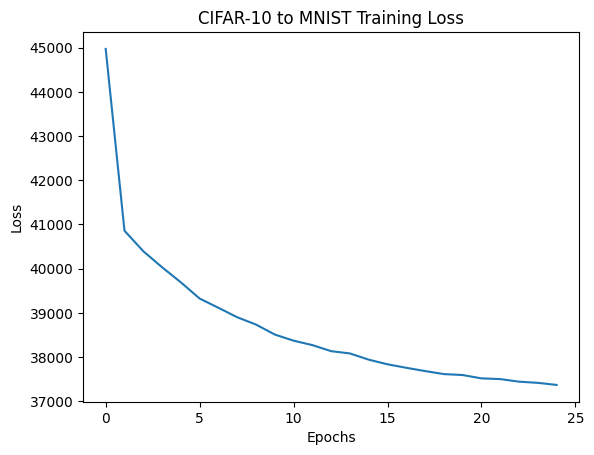

In [18]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR-10 to MNIST Training Loss')

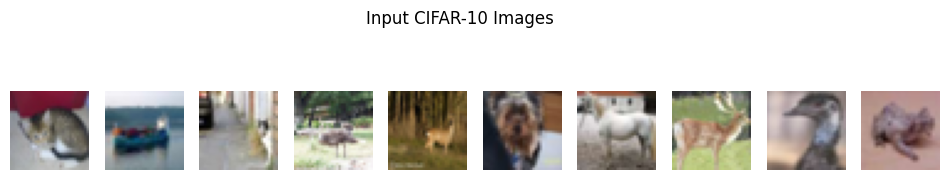

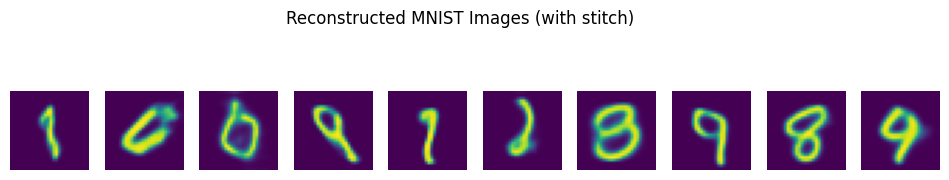

In [19]:
# Sample CIFAR-10 images
data = next(iter(cifar_test_loader))
inputs = data[0]

# Plot starting examples
total_images = 10
fig, ax= plt.subplots(1, total_images, figsize=(12, 2.5))
fig.suptitle('Input CIFAR-10 Images')
for i in range(total_images):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output, _ = cifar_to_mnist_model(inputs.to(device))


# Plot reconstructed images
fig, ax= plt.subplots(1, total_images, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images (with stitch)')
for i in range(total_images):
    ax[i].imshow(output[i,0,:,:].detach().cpu().numpy())
    ax[i].axis('off')
plt.show()


## Dataset

For training the stitch we will match CIFAR-10 to MNIST images in a one-to-one fashion.  Classes should also match up.  For instance, images of airplanes in CIFAR-10 should always be mapped images of 0's in MNIST.

In [20]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import numpy as np

class MNISTCIFARDataset(Dataset):
    def __init__(self, mnist_root='./data', cifar_root='./data', train=True):
        # Load datasets
        self.mnist = datasets.MNIST(root=mnist_root, train=train, download=True,
                                  transform=transforms.ToTensor())
        self.cifar = datasets.CIFAR10(root=cifar_root, train=train, download=True,
                                    transform=transforms.ToTensor())

        # Get indices for each class
        self.mnist_indices = self._get_class_indices(self.mnist)
        self.cifar_indices = self._get_class_indices(self.cifar)

        # Calculate number of samples per class to use
        self.samples_per_class = min(
            min(len(indices) for indices in self.mnist_indices),
            min(len(indices) for indices in self.cifar_indices)
        )

        # Restict lists of indicies to be the same size
        self.mnist_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.mnist_indices]
        self.mnist_indices = sum(self.mnist_indices, [])
        self.cifar_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.cifar_indices]
        self.cifar_indices = sum(self.cifar_indices, [])

    def _get_class_indices(self, dataset):
        indices = [[] for _ in range(10)]
        for idx, (_, label) in enumerate(dataset):
            indices[label].append(idx)
        return indices

    def __getitem__(self, idx):

        # Get MNIST sample
        mnist_idx = self.mnist_indices[idx]
        mnist_img, mnist_label = self.mnist[mnist_idx]

        # Get corresponding cifar sample
        cifar_idx = self.cifar_indices[idx]
        cifar_img, cifar_label = self.cifar[cifar_idx]

        return {
            'mnist_image': mnist_img,
            'mnist_label': mnist_label,
            'cifar_image': cifar_img,
            'cifar_label': cifar_label
        }

    def __len__(self):
        return len(self.mnist_indices)

combined_dataset = MNISTCIFARDataset()
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


Display matched up MNIST and CIFAR-10 images.

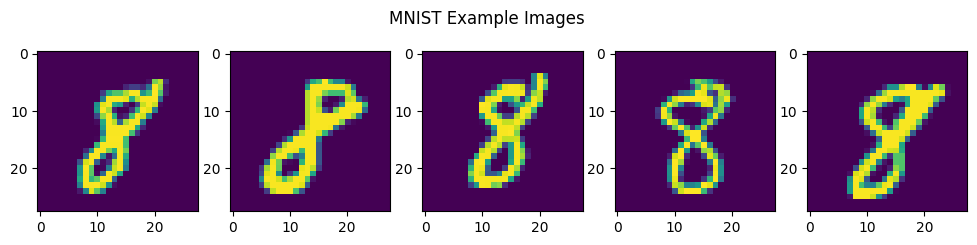

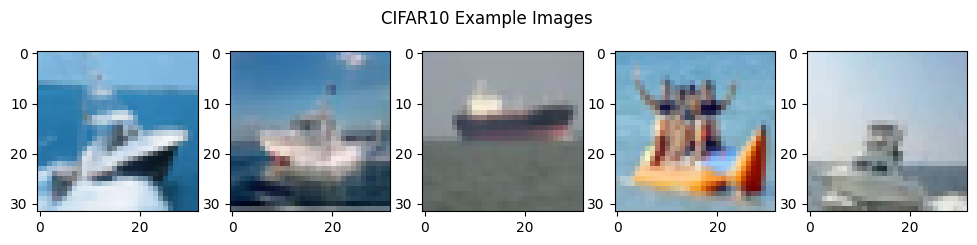

In [21]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
for i in range(5):
    ax[i].imshow(combined_dataset[40000+i]['mnist_image'][0,:,:].numpy())
plt.show()

# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('CIFAR10 Example Images')
for i in range(5):
    ax[i].imshow(np.transpose(combined_dataset[40000+i]['cifar_image'].numpy(), (1,2,0)))
plt.show()

## Cluster-to-Cluster Stitch Training

Train a stitch between the CIFAR-10 encoder and the MNIST decoder.  In this case, match classes in one dataset to classes in the other.  Each image in CIFAR-10 is assigned to an MNIST image according to the following mappings:

<u>**CIFAR-10 to MNIST Mappings**</u>
      
airplane $\rightarrow$ 0

automobile $\rightarrow$ 1

bird $\rightarrow$ 2

cat $\rightarrow$ 3

deer $\rightarrow$ 4

dog $\rightarrow$ 5

frog $\rightarrow$ 6

horse $\rightarrow$ 7

ship $\rightarrow$ 8

truck $\rightarrow$ 9

In [22]:
cifar_to_mnist_model_2 = StichedAutoencoder(cifar_model.encoder, mnist_model.decoder, bottleneck_size).to(device)

# Put top model into train mode so that bn and dropout perform in training mode
cifar_to_mnist_model_2.train()
# Freeze the top model
cifar_to_mnist_model_2.requires_grad_(False)
# Un-Freeze the stitch layer
for name, param in cifar_to_mnist_model_2.stitch.named_parameters():
    param.requires_grad_(True)

In [23]:
# define the loss function and the optimiser
criterion = nn.MSELoss()
optimiser = optim.SGD(cifar_to_mnist_model_2.parameters(), lr=1e-2, momentum=0.9, weight_decay=0.01)

stitch_train_epochs = 20
loss_history = []
for epoch in range(stitch_train_epochs):
    running_loss = 0.0
    for data in combined_loader:

        # get data and put it on the GPU
        inputs, targets = data['cifar_image'], data['mnist_image']
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero the parameter gradients
        optimiser.zero_grad()

        # forward + loss + backward + optimise (update weights)
        outputs, _ = cifar_to_mnist_model_2(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimiser.step()

        # keep track of the loss this epoch
        running_loss += loss.item()

    # Log training losses
    avg_loss = running_loss / len(combined_loader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{stitch_train_epochs}], Loss: {avg_loss:.6f}')

Epoch [1/20], Loss: 0.092859
Epoch [2/20], Loss: 0.082656
Epoch [3/20], Loss: 0.077348
Epoch [4/20], Loss: 0.074445
Epoch [5/20], Loss: 0.072768
Epoch [6/20], Loss: 0.071740
Epoch [7/20], Loss: 0.071072
Epoch [8/20], Loss: 0.070606
Epoch [9/20], Loss: 0.070247
Epoch [10/20], Loss: 0.069987
Epoch [11/20], Loss: 0.069796
Epoch [12/20], Loss: 0.069677
Epoch [13/20], Loss: 0.069601
Epoch [14/20], Loss: 0.069530
Epoch [15/20], Loss: 0.069506
Epoch [16/20], Loss: 0.069483
Epoch [17/20], Loss: 0.069477
Epoch [18/20], Loss: 0.069481
Epoch [19/20], Loss: 0.069504
Epoch [20/20], Loss: 0.069542


Text(0.5, 1.0, 'CIFAR10 to MNIST Training Loss')

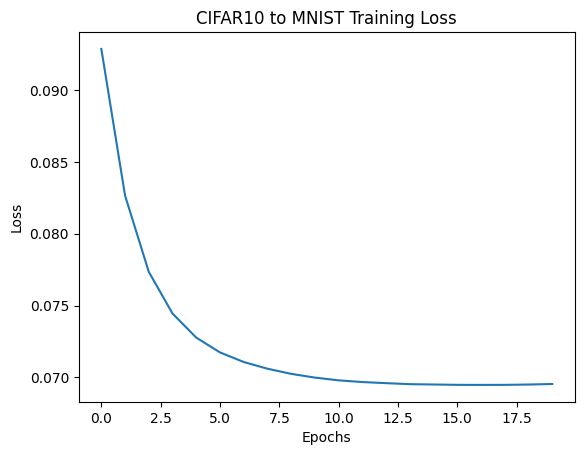

In [24]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR10 to MNIST Training Loss')

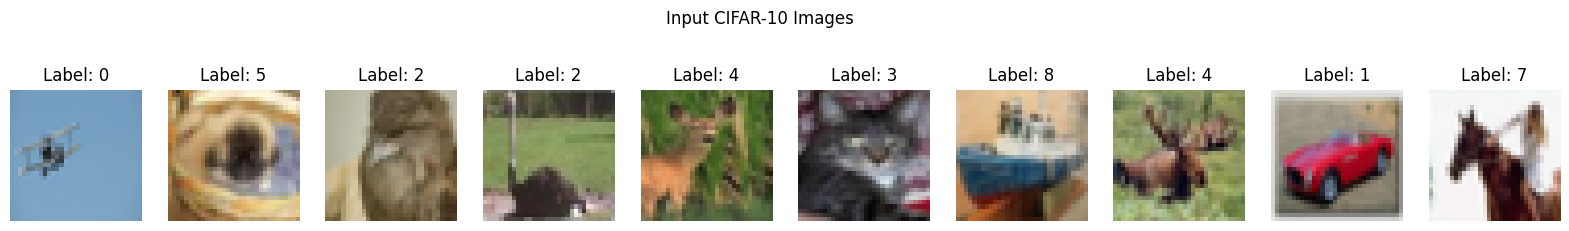

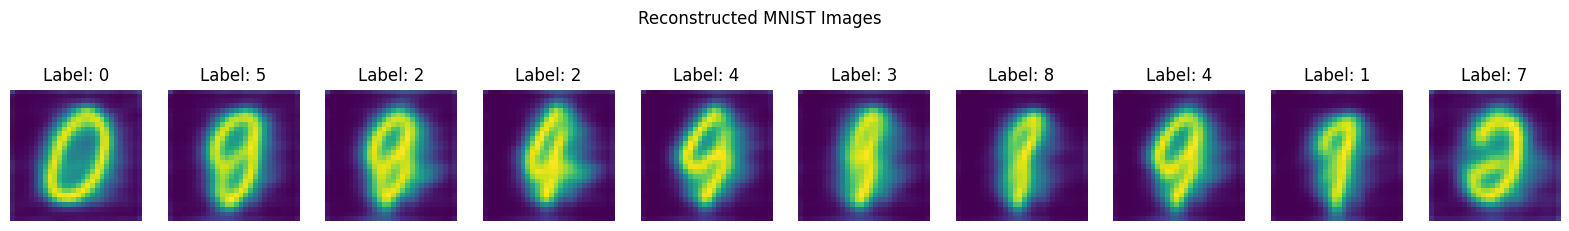

In [25]:
# Sample CIFAR-10 images
data = next(iter(cifar_test_loader))
inputs, labels = data[0], data[1]

# Plot starting examples
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Input CIFAR-10 Images')
for i in range(10):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output, _ = cifar_to_mnist_model_2(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images')
for i in range(10):
    ax[i].imshow(output[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Principle Component Analysis

Let's try to cluster bottleneck features in each autoencoder

In [26]:
colors = {0:'red', 1:'orange', 2:'yellow', 3: 'yellowgreen', 4: 'lime', 5: 'cyan', 6: 'blue', 7: 'indigo', 8: 'plum', 9: 'black'}

In [27]:
mnist_bottleneck_points = np.zeros((0, bottleneck_size))
mnist_labels = np.zeros(0)
for data in mnist_loader:
    # Sample data from dataset
    img, labels = data
    bn = mnist_model.encoder(img.to(device))
    mnist_bottleneck_points = np.concatenate([mnist_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    mnist_labels = np.concatenate([mnist_labels, labels.numpy()], axis=0)


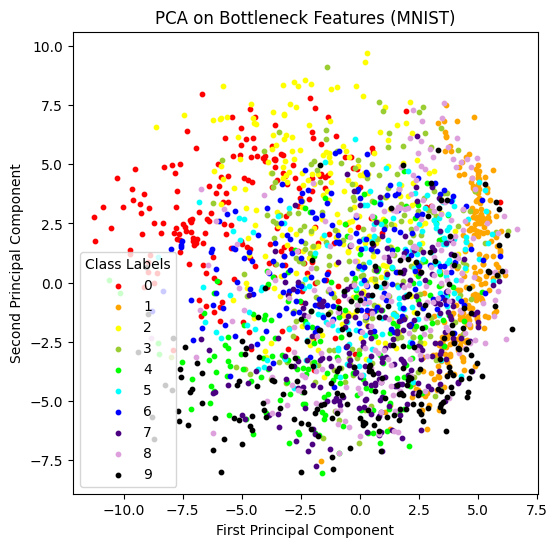

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
total_points = 2000
X_pca = pca.fit_transform(mnist_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (MNIST)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[mnist_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')

In [29]:
cifar_bottleneck_points = np.zeros((0, bottleneck_size))
cifar_labels = np.zeros(0)
for data in cifar_loader:
    # Sample data from dataset
    img, labels = data
    bn = cifar_model.encoder(img.to(device))
    cifar_bottleneck_points = np.concatenate([cifar_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    cifar_labels = np.concatenate([cifar_labels, labels.numpy()], axis=0)


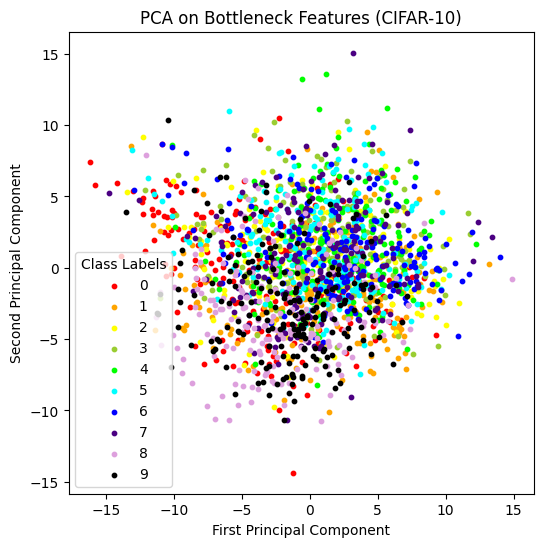

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cifar_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (CIFAR-10)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[cifar_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')

# Save Images

Finally, lets generated some images using our stitched models, and then save the corresponding outputs.

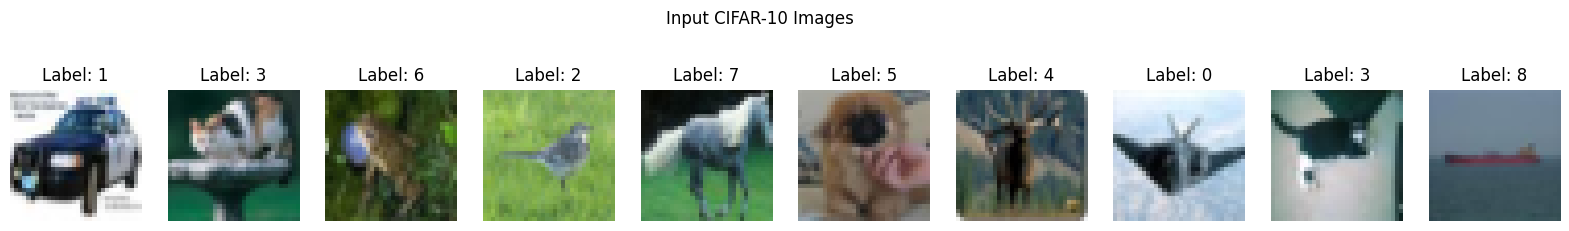

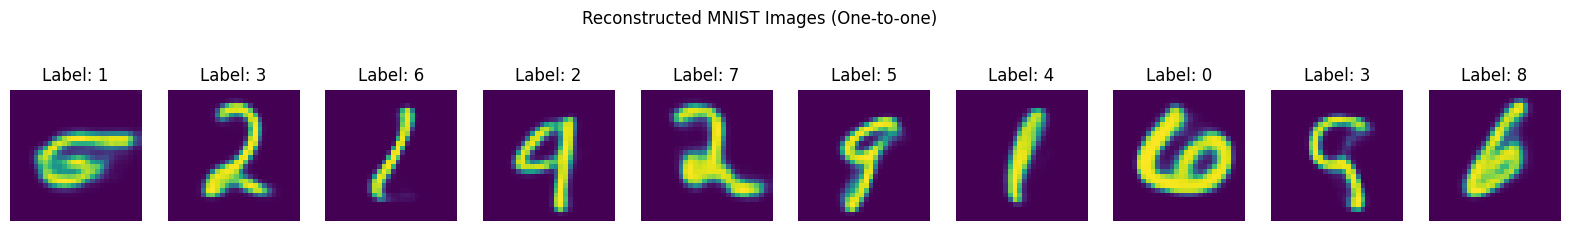

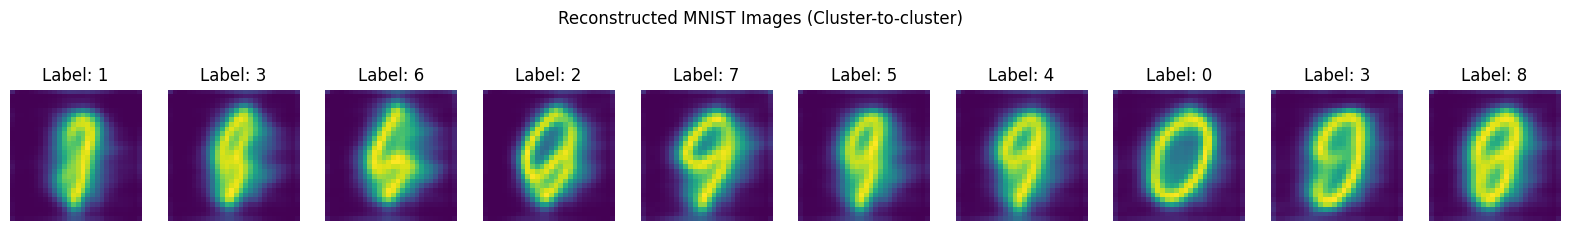

In [59]:
# Sample CIFAR-10 images
data = next(iter(cifar_test_loader))
inputs, labels = data[0], data[1]

# Plot starting examples
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Input CIFAR-10 Images')
for i in range(10):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output1, _ = cifar_to_mnist_model(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images (One-to-one)')
for i in range(10):
    ax[i].imshow(output1[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output2, _ = cifar_to_mnist_model_2(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images (Cluster-to-cluster)')
for i in range(10):
    ax[i].imshow(output2[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

In [60]:
import torch
import torchvision.utils as vutils
import os

def save_tensor_as_images(tensor, filename_root, output_dir='output_dir', normalize=True):
    """
    Save a PyTorch tensor of images as individual PNG files.

    Args:
    - tensor (torch.Tensor): Input tensor of shape (N, C, H, W)
    - output_dir (str): Directory to save images
    - normalize (bool): Normalize images to [0, 1] range if True
    """
    os.makedirs(output_dir, exist_ok=True)

    # Handle both grayscale and RGB tensors
    if tensor.dim() == 4:
        for i in range(tensor.size(0)):
            img = tensor[i]
            if normalize:
                img = (img - img.min()) / (img.max() - img.min())
            vutils.save_image(img, os.path.join(output_dir, filename_root + f'_{i}.png'))

In [61]:
save_tensor_as_images(torch.clamp(inputs[:32].detach().cpu(), 0, 1), 'in')
save_tensor_as_images(torch.clamp(output1[:32].detach().cpu(), 0, 1), 'out_one_to_one')
save_tensor_as_images(torch.clamp(output2[:32].detach().cpu(), 0, 1), 'out_cluster_to_cluster')

In [62]:
!zip -r /content/outputs.zip /content/output_dir

updating: content/output_dir/ (stored 0%)
updating: content/output_dir/out_one_to_one_27.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_13.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_15.png (stored 0%)
updating: content/output_dir/in_19.png (stored 0%)
updating: content/output_dir/in_30.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_1.png (stored 0%)
updating: content/output_dir/in_21.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_24.png (stored 0%)
updating: content/output_dir/out_one_to_one_30.png (stored 0%)
updating: content/output_dir/out_one_to_one_28.png (stored 0%)
updating: content/output_dir/out_one_to_one_24.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_26.png (stored 0%)
updating: content/output_dir/out_one_to_one_3.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_5.png (stored 0%)
updating: content/output_dir/out_cluster_to_cluster_16.png (stored 

In [63]:
from google.colab import files
files.download("/content/outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>